# Taller 1: Gobierno Corporativo y desempeño de la firma

Inversión ASG 2025-1 · Maestría en Administración Financiera · Universidad EAFIT

Este cuaderno sigue los tres puntos del enunciado sobre `07. T1_GC_datos.xlsx`:

1. **Análisis descriptivo** de puntajes ASG, características de la junta directiva,
   compensación ejecutiva y mecanismos antitoma de control.
2. **Análisis de correlación** (covarianza y coeficientes de correlación) entre las
   características de gobierno y las medidas de desempeño.
3. **Análisis de regresión** para explorar la relación **no lineal** entre gobierno y desempeño,
   y discusión de los **problemas de endogeneidad**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_excel("07. T1_GC_datos.xlsx", sheet_name="datos")
df = df.drop(columns=[c for c in df.columns if c.endswith(".1")])

RENOMBRES = {
    "BESG Governance Pillar Score": "G",
    "BESG ESG Score": "ESG",
    "BESG Environmental Pillar Score": "E",
    "BESG Social Pillar Score": "S",
    "Governance Disclosure Score": "DivulgGob",
    "Return on Common Equity": "ROE",
    "Return on Assets": "ROA",
    "ROIC/WACC Ratio": "ROIC_WACC",
    "Weighted Average Cost of Cap": "WACC",
    "Operating Margin": "MargenOp",
    "Price to Book Ratio": "PB",
    "Current Market Cap": "MCAP",
    "Revenue": "Ingresos",
    "Industry Sector": "Sector",
    "Total Debt to Total Assets": "DeudaActivos",
    "Board Size": "TamJunta",
    "Board Average Age": "EdadJunta",
    "Number of Independent Directors": "NIndep",
    "% Women on Board": "PctMujeresJunta",
    "CEO Duality": "Dualidad",
    "Classified Board System": "JuntaEscalonada",
    "Poison Pill Plan": "PoisonPill",
    "Chg of Ctrl Benefits/Golden Parachute Agreements": "ParacaidasDorado",
    "Total Compensation Paid to Executives": "CompEjec",
    "Total Compensation Paid to CEO and Equivalent": "CompCEO",
    "Total Board of Director Compensation Paid": "CompJunta",
    "Number of Employees": "Empleados",
}
df = df.rename(columns=RENOMBRES)

df["logMC"] = np.log(df["MCAP"].where(df["MCAP"] > 0))
df["PctIndep"] = df["NIndep"] / df["TamJunta"] * 100

# Mecanismos antitoma de control: el archivo los trae como texto "Y"/"N".
# En pandas 3.0 estas columnas llegan con dtype `str`, no `object`; conviene
# mapearlas de forma explícita y no condicionar el mapeo al dtype.
BINARIAS = {
    "Dualidad": "dual",
    "JuntaEscalonada": "escalonada",
    "PoisonPill": "poison",
    "ParacaidasDorado": "paracaidas",
}
for origen, destino in BINARIAS.items():
    df[destino] = pd.to_numeric(df[origen].map({"Y": 1, "N": 0}), errors="coerce")

DESEMPENO = ["ROA", "ROE", "ROIC_WACC", "MargenOp", "WACC", "PB"]
JUNTA = ["PctIndep", "TamJunta", "EdadJunta", "PctMujeresJunta"]
BLINDAJE = ["dual", "escalonada", "poison", "paracaidas"]

def winsorizar(s, p=0.01):
    lo, hi = s.quantile([p, 1 - p])
    return s.clip(lo, hi)

dfw = df.copy()
for c in DESEMPENO:
    dfw[c] = winsorizar(dfw[c])

print(f"Empresas: {len(df):,}   Sectores: {df['Sector'].nunique()}")
print("\nCobertura de los mecanismos antitoma de control (dato informado):")
pd.DataFrame({
    "n_informado": [df[v].notna().sum() for v in BLINDAJE],
    "n_con_mecanismo": [int(df[v].sum()) for v in BLINDAJE],
    "pct_con_mecanismo": [df[v].mean() * 100 for v in BLINDAJE],
}, index=["Dualidad del CEO", "Junta escalonada", "Poison pill", "Paracaídas dorado"])

Empresas: 1,878   Sectores: 10

Cobertura de los mecanismos antitoma de control (dato informado):


,n_informado,n_con_mecanismo,pct_con_mecanismo
Dualidad del CEO,442,154,34.842
Junta escalonada,428,142,33.178
Poison pill,1117,11,0.985
Paracaídas dorado,432,343,79.398


## 1. Análisis descriptivo

### 1.1 Puntajes ASG: media, varianza, rango

In [2]:
def descriptivos(d, cols):
    t = pd.DataFrame({
        "n": d[cols].notna().sum(),
        "media": d[cols].mean(),
        "varianza": d[cols].var(),
        "desv_est": d[cols].std(),
        "min": d[cols].min(),
        "p25": d[cols].quantile(0.25),
        "mediana": d[cols].median(),
        "p75": d[cols].quantile(0.75),
        "max": d[cols].max(),
    })
    t["rango"] = t["max"] - t["min"]
    t["coef_variacion"] = t["desv_est"] / t["media"]
    return t

tabla_asg = descriptivos(df, ["ESG", "E", "S", "G"])
tabla_asg

,n,media,varianza,desv_est,min,p25,mediana,p75,max,rango,coef_variacion
ESG,1433,3.971,2.298,1.516,0.780,2.680,3.960,5.120,8.470,7.690,0.382
E,1433,2.884,5.478,2.341,0.000,0.499,2.873,4.706,9.428,9.428,0.812
S,1433,3.287,4.478,2.116,0.000,1.625,2.742,4.554,10.000,10.000,0.644
G,1433,6.920,1.352,1.163,2.019,6.360,7.142,7.740,9.097,7.078,0.168


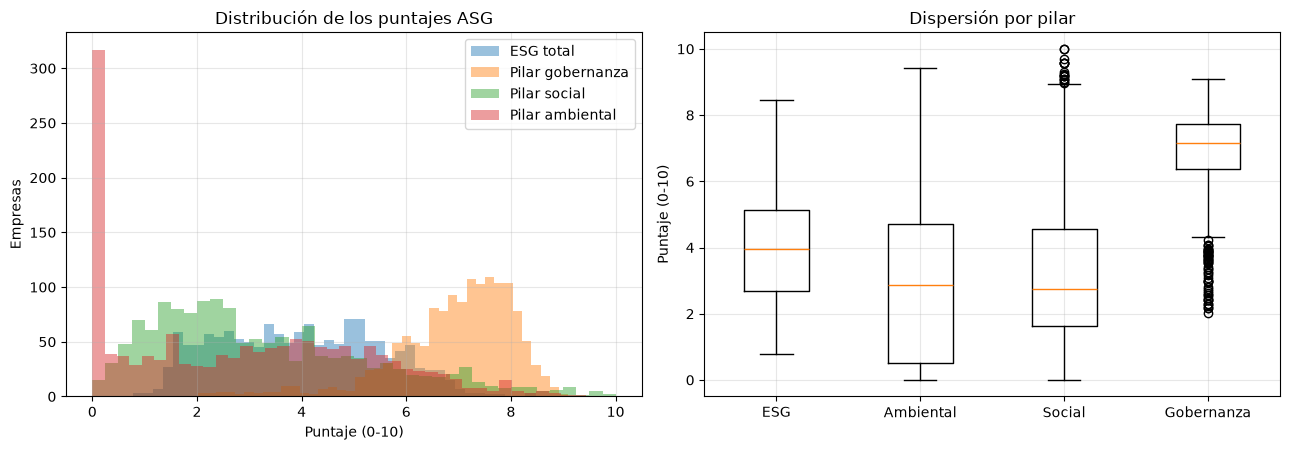

El pilar de gobernanza tiene la media más alta y la varianza más baja de los tres:
   media  varianza  rango
E  2.884     5.478  9.428
S  3.287     4.478 10.000
G  6.920     1.352  7.078


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

for c, etiqueta in [("ESG", "ESG total"), ("G", "Pilar gobernanza"),
                    ("S", "Pilar social"), ("E", "Pilar ambiental")]:
    ax[0].hist(df[c].dropna(), bins=40, alpha=0.45, label=etiqueta)
ax[0].set_title("Distribución de los puntajes ASG")
ax[0].set_xlabel("Puntaje (0-10)"); ax[0].set_ylabel("Empresas"); ax[0].legend()

ax[1].boxplot([df[c].dropna() for c in ["ESG", "E", "S", "G"]],
              tick_labels=["ESG", "Ambiental", "Social", "Gobernanza"])
ax[1].set_title("Dispersión por pilar")
ax[1].set_ylabel("Puntaje (0-10)")
plt.tight_layout(); plt.show()

print("El pilar de gobernanza tiene la media más alta y la varianza más baja de los tres:")
print(tabla_asg.loc[["E", "S", "G"], ["media", "varianza", "rango"]])

### 1.2 Características de la junta directiva

In [4]:
tabla_junta = descriptivos(df, JUNTA)
tabla_junta

,n,media,varianza,desv_est,min,p25,mediana,p75,max,rango,coef_variacion
PctIndep,381,78.071,241.821,15.551,27.273,71.429,83.333,90.000,93.750,66.477,0.199
TamJunta,438,9.655,4.652,2.157,3.000,8.000,10.000,11.000,17.000,14.000,0.223
EdadJunta,432,61.004,28.349,5.324,42.250,58.534,61.775,64.377,80.400,38.150,0.087
PctMujeresJunta,437,28.911,127.379,11.286,0.000,22.222,30.000,36.364,66.667,66.667,0.390


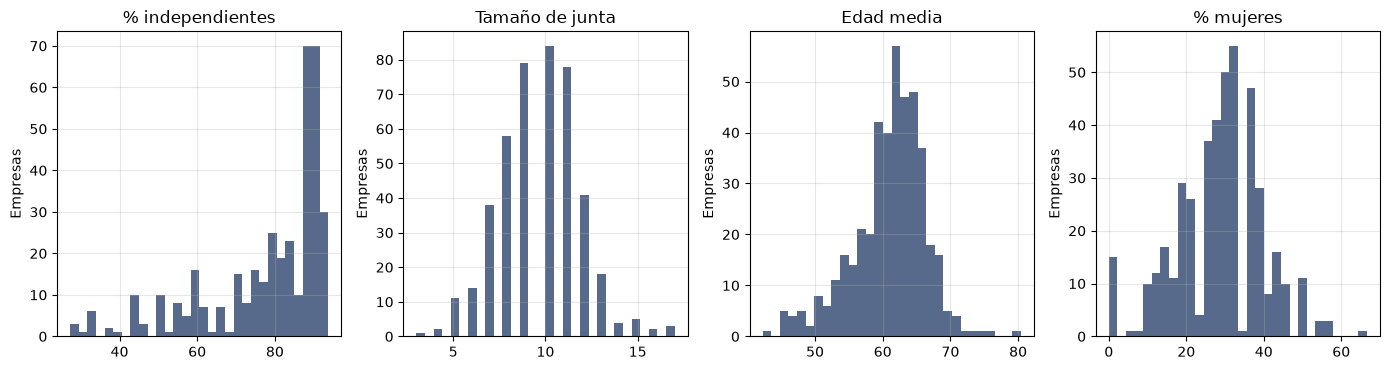

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.8))
etiquetas = {"PctIndep": "% independientes", "TamJunta": "Tamaño de junta",
             "EdadJunta": "Edad media", "PctMujeresJunta": "% mujeres"}
for a, c in zip(ax, JUNTA):
    a.hist(df[c].dropna(), bins=30, color="#1f3864", alpha=0.75)
    a.set_title(etiquetas[c]); a.set_ylabel("Empresas")
plt.tight_layout(); plt.show()

### 1.3 Compensación ejecutiva

Compensación en USD:


,n,media,desv_est,min,mediana,max,coef_variacion
CompEjec,1396,"33,633,910.120","51,940,628.083",0.000,"25,427,460.500","1,607,000,000.000",1.544
CompCEO,1363,"14,177,904.617","15,864,492.514",0.000,"10,825,450.000","246,230,000.000",1.119
CompJunta,1399,"2,748,827.800","1,889,198.499",0.000,"2,554,933.000","35,226,975.600",0.687


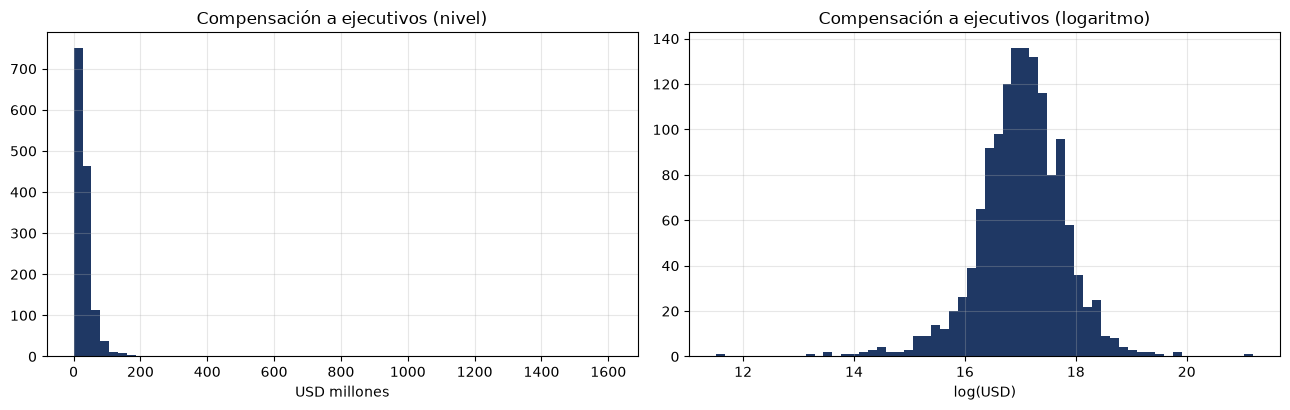

Asimetría de la compensación a ejecutivos: 20.91
Media / mediana = 1.32


In [6]:
COMP = ["CompEjec", "CompCEO", "CompJunta"]
tabla_comp = descriptivos(df, COMP)
print("Compensación en USD:")
display(tabla_comp[["n", "media", "desv_est", "min", "mediana", "max", "coef_variacion"]])

# La compensación es fuertemente asimétrica: la media supera con creces a la mediana.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(df["CompEjec"].dropna() / 1e6, bins=60, color="#1f3864")
ax[0].set_title("Compensación a ejecutivos (nivel)"); ax[0].set_xlabel("USD millones")
ax[1].hist(np.log(df["CompEjec"].where(df["CompEjec"] > 0)).dropna(), bins=60, color="#1f3864")
ax[1].set_title("Compensación a ejecutivos (logaritmo)"); ax[1].set_xlabel("log(USD)")
plt.tight_layout(); plt.show()

print("Asimetría de la compensación a ejecutivos:", round(df["CompEjec"].skew(), 2))
print("Media / mediana =", round(df["CompEjec"].mean() / df["CompEjec"].median(), 2))

### 1.4 Mecanismos antitoma de control

El enunciado pide explícitamente describir estos mecanismos. El archivo trae cuatro:
dualidad del CEO, junta escalonada (*classified board*), *poison pill* y paracaídas dorado.
Los cuatro llegan como texto `"Y"`/`"N"`.

In [7]:
prevalencia = pd.DataFrame({
    "n_informado": [df[v].notna().sum() for v in BLINDAJE],
    "con_mecanismo": [int(df[v].sum()) for v in BLINDAJE],
    "sin_mecanismo": [int((1 - df[v]).sum()) for v in BLINDAJE],
    "prevalencia_%": [df[v].mean() * 100 for v in BLINDAJE],
}, index=["Dualidad del CEO", "Junta escalonada", "Poison pill", "Paracaídas dorado"])
print("Prevalencia de mecanismos antitoma de control:")
display(prevalencia)

# Índice de blindaje: cuántos mecanismos acumula cada empresa
df["n_blindaje"] = df[BLINDAJE].sum(axis=1, min_count=1)
df["blindaje_informado"] = df[BLINDAJE].notna().sum(axis=1)
completos = df[df["blindaje_informado"] == 4]
print(f"\nEmpresas con los cuatro mecanismos informados: {len(completos):,}")
print("Distribución del número de mecanismos acumulados:")
display(completos["n_blindaje"].value_counts().sort_index().to_frame("empresas"))

Prevalencia de mecanismos antitoma de control:


,n_informado,con_mecanismo,sin_mecanismo,prevalencia_%
Dualidad del CEO,442,154,288,34.842
Junta escalonada,428,142,286,33.178
Poison pill,1117,11,1106,0.985
Paracaídas dorado,432,343,89,79.398



Empresas con los cuatro mecanismos informados: 388
Distribución del número de mecanismos acumulados:


,empresas
n_blindaje,
0.000,28
1.000,182
2.000,135
3.000,43


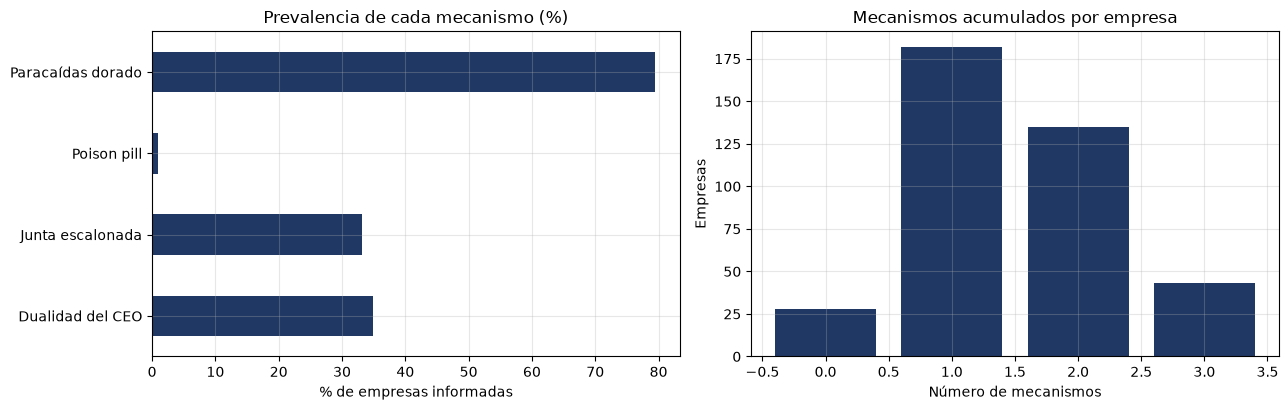

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

prevalencia["prevalencia_%"].plot(kind="barh", ax=ax[0], color="#1f3864")
ax[0].set_title("Prevalencia de cada mecanismo (%)"); ax[0].set_xlabel("% de empresas informadas")

conteo = completos["n_blindaje"].value_counts().sort_index()
ax[1].bar(conteo.index.astype(int), conteo.values, color="#1f3864")
ax[1].set_title("Mecanismos acumulados por empresa")
ax[1].set_xlabel("Número de mecanismos"); ax[1].set_ylabel("Empresas")
plt.tight_layout(); plt.show()

In [9]:
# ¿Los mecanismos van juntos? Correlación entre ellos.
print("Correlación entre mecanismos (empresas con los cuatro informados):")
display(completos[BLINDAJE].corr().round(3))

# ¿Cómo los trata el puntaje de gobierno de Bloomberg?
print("\nPuntaje de gobierno medio según cada mecanismo:")
filas = []
for v, etiqueta in zip(BLINDAJE, ["Dualidad del CEO", "Junta escalonada",
                                  "Poison pill", "Paracaídas dorado"]):
    d = df[[v, "G"]].dropna()
    con, sin = d.loc[d[v] == 1, "G"], d.loc[d[v] == 0, "G"]
    filas.append({
        "mecanismo": etiqueta, "n_con": len(con), "n_sin": len(sin),
        "G_con": con.mean() if len(con) else np.nan,
        "G_sin": sin.mean() if len(sin) else np.nan,
        "diferencia": (con.mean() - sin.mean()) if len(con) and len(sin) else np.nan,
    })
tabla_blindaje_G = pd.DataFrame(filas).set_index("mecanismo")
display(tabla_blindaje_G)

Correlación entre mecanismos (empresas con los cuatro informados):


,dual,escalonada,poison,paracaidas
dual,1.000,0.047,0.035,-0.010
escalonada,0.047,1.000,-0.072,-0.012
poison,0.035,-0.072,1.000,-0.017
paracaidas,-0.010,-0.012,-0.017,1.000



Puntaje de gobierno medio según cada mecanismo:


,n_con,n_sin,G_con,G_sin,diferencia
mecanismo,,,,,
Dualidad del CEO,152,277,6.295,6.672,-0.378
Junta escalonada,135,279,5.924,6.889,-0.965
Poison pill,11,1095,6.447,6.907,-0.460
Paracaídas dorado,331,87,6.869,5.145,1.724


## 2. Análisis de correlación

La rúbrica pide **covarianza** y **coeficientes de correlación**. Se reportan las dos:
la covarianza conserva las unidades de cada par de variables y por eso no es comparable
entre pares; la correlación es la covarianza estandarizada y sí lo es.

In [10]:
GOBIERNO = ["G", "PctIndep", "TamJunta", "EdadJunta", "PctMujeresJunta"] + BLINDAJE
pares = dfw[GOBIERNO + DESEMPENO]

cov = pares.cov().loc[GOBIERNO, DESEMPENO]
print("Matriz de COVARIANZAS (gobierno x desempeño):")
display(cov.round(3))

print("\nMismo par, dos escalas: la covarianza depende de las unidades.")
d = dfw[["TamJunta", "PctIndep", "ROA"]].dropna()
print(f"  Cov(TamJunta, ROA)  = {d['TamJunta'].cov(d['ROA']):,.3f}  (directores x %)")
print(f"  Cov(PctIndep, ROA)  = {d['PctIndep'].cov(d['ROA']):,.3f}  (% x %)")
print(f"  Corr(TamJunta, ROA) = {d['TamJunta'].corr(d['ROA']):,.3f}")
print(f"  Corr(PctIndep, ROA) = {d['PctIndep'].corr(d['ROA']):,.3f}")

Matriz de COVARIANZAS (gobierno x desempeño):


,ROA,ROE,ROIC_WACC,MargenOp,WACC,PB
G,1.623,5.444,0.361,7.060,-0.890,-1.061
PctIndep,19.442,45.057,4.848,81.222,-12.314,-2.383
TamJunta,3.638,13.443,0.698,22.230,-1.633,-1.598
EdadJunta,12.506,34.446,1.819,36.016,-4.459,-1.719
PctMujeresJunta,19.292,56.897,3.092,80.341,-7.801,4.582
dual,-0.332,-0.991,-0.086,-1.000,0.124,0.524
escalonada,-0.696,-2.131,-0.101,-2.241,0.218,-0.024
poison,0.045,0.029,0.002,0.079,-0.001,-0.041
paracaidas,0.163,0.286,0.041,1.219,-0.135,-0.048



Mismo par, dos escalas: la covarianza depende de las unidades.
  Cov(TamJunta, ROA)  = 2.865  (directores x %)
  Cov(PctIndep, ROA)  = 19.442  (% x %)
  Corr(TamJunta, ROA) = 0.115
  Corr(PctIndep, ROA) = 0.110


Correlación de PEARSON (lineal):


,ROA,ROE,ROIC_WACC,MargenOp,WACC,PB
G,0.131,0.164,0.186,0.134,-0.372,-0.076
PctIndep,0.110,0.098,0.178,0.131,-0.329,-0.015
TamJunta,0.138,0.210,0.171,0.204,-0.315,-0.063
EdadJunta,0.191,0.209,0.181,0.133,-0.347,-0.027
PctMujeresJunta,0.140,0.170,0.145,0.142,-0.287,0.035
dual,-0.059,-0.069,-0.098,-0.049,0.110,0.093
escalonada,-0.121,-0.151,-0.113,-0.091,0.193,-0.005
poison,0.045,0.010,0.013,0.017,-0.005,-0.035
paracaidas,0.034,0.023,0.054,0.059,-0.139,-0.011


Correlación de SPEARMAN (monótona, robusta a valores extremos):


,ROA,ROE,ROIC_WACC,MargenOp,WACC,PB
G,0.120,0.149,0.208,0.169,-0.320,-0.144
PctIndep,0.097,0.129,0.238,0.062,-0.280,-0.007
TamJunta,0.104,0.236,0.211,0.122,-0.314,-0.025
EdadJunta,0.142,0.187,0.174,0.143,-0.261,-0.108
PctMujeresJunta,0.100,0.151,0.166,0.007,-0.275,0.049
dual,-0.067,-0.074,-0.065,-0.103,0.068,0.098
escalonada,-0.114,-0.154,-0.161,-0.137,0.240,0.078
poison,0.034,0.036,0.009,0.019,-0.005,-0.057
paracaidas,0.001,-0.003,0.094,-0.050,-0.122,0.021


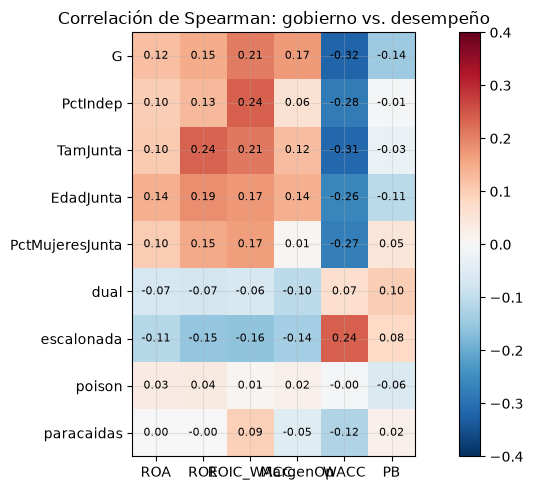

In [11]:
corr_p = pares.corr(method="pearson").loc[GOBIERNO, DESEMPENO]
corr_s = pares.corr(method="spearman").loc[GOBIERNO, DESEMPENO]

print("Correlación de PEARSON (lineal):")
display(corr_p.round(3))
print("Correlación de SPEARMAN (monótona, robusta a valores extremos):")
display(corr_s.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(corr_s.values, cmap="RdBu_r", vmin=-0.4, vmax=0.4)
ax.set_xticks(range(len(DESEMPENO)), DESEMPENO)
ax.set_yticks(range(len(GOBIERNO)), GOBIERNO)
for i in range(len(GOBIERNO)):
    for j in range(len(DESEMPENO)):
        v = corr_s.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlación de Spearman: gobierno vs. desempeño")
plt.colorbar(im); plt.tight_layout(); plt.show()

## 3. Regresión: la relación entre gobierno y desempeño es no lineal

El enunciado pide explícitamente explorar la relación **no lineal**. Se comparan tres
especificaciones para cada medida de desempeño:

- **Lineal:** `y = a + b·G`
- **Cuadrática:** `y = a + b₁·G + b₂·G²`
- **Escalonada:** dummies por quintil de G, que no impone ninguna forma funcional

Todas con controles de tamaño (log del market cap), apalancamiento y efectos fijos de sector,
y errores estándar robustos a heterocedasticidad (HC1).

In [12]:
base = dfw.dropna(subset=["G", "logMC", "Sector"]).copy()
base["G2"] = base["G"] ** 2
base["qG"] = pd.qcut(base["G"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

CONTROLES = "+ logMC + DeudaActivos + C(Sector)"

def ajustar(formula, datos):
    return smf.ols(formula, data=datos).fit(cov_type="HC1")

comparacion = []
modelos = {}
for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC"]:
    d = base.dropna(subset=[y, "DeudaActivos"])
    m_lin = ajustar(f"{y} ~ G {CONTROLES}", d)
    m_cua = ajustar(f"{y} ~ G + G2 {CONTROLES}", d)
    m_esc = ajustar(f"{y} ~ C(qG) {CONTROLES}", d)
    modelos[y] = (m_lin, m_cua, m_esc)

    # Prueba F: ¿el término cuadrático aporta?
    f_test = m_cua.f_test("G2 = 0")
    # Punto de quiebre de la parábola
    b1, b2 = m_cua.params["G"], m_cua.params["G2"]
    vertice = -b1 / (2 * b2) if b2 != 0 else np.nan

    comparacion.append({
        "desempeno": y, "n": int(m_lin.nobs),
        "b_lineal": m_lin.params["G"],
        "b_G": b1, "b_G2": b2,
        "p_G2": float(np.ravel(f_test.pvalue)[0]),
        "vertice_G": vertice,
        "R2_lineal": m_lin.rsquared, "R2_cuadratico": m_cua.rsquared,
        "R2_escalonado": m_esc.rsquared,
    })

tabla_nolineal = pd.DataFrame(comparacion).set_index("desempeno")
print("Lineal vs. cuadrático vs. escalonado (con controles y efectos fijos de sector):")
tabla_nolineal

Lineal vs. cuadrático vs. escalonado (con controles y efectos fijos de sector):


,n,b_lineal,b_G,b_G2,p_G2,vertice_G,R2_lineal,R2_cuadratico,R2_escalonado
desempeno,,,,,,,,,
ROA,1431,0.882,-2.962,0.313,0.007,4.736,0.121,0.125,0.136
ROE,1354,2.640,-2.999,0.459,0.217,3.264,0.132,0.134,0.143
MargenOp,1417,3.808,-14.869,1.520,0.000,4.891,0.106,0.111,0.117
ROIC_WACC,1432,0.207,-0.502,0.058,0.005,4.351,0.112,0.118,0.126
WACC,1432,-0.550,-0.707,0.013,0.645,27.631,0.322,0.322,0.311


In [13]:
# Rango observado de G, para saber si el vértice cae dentro de los datos
print(f"Rango de G en la muestra: {base['G'].min():.2f} a {base['G'].max():.2f}")
print(f"Percentiles 5 y 95:       {base['G'].quantile(0.05):.2f} a {base['G'].quantile(0.95):.2f}\n")

for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC"]:
    fila = tabla_nolineal.loc[y]
    dentro = base["G"].min() <= fila["vertice_G"] <= base["G"].max()
    forma = "cóncava (rendimientos decrecientes)" if fila["b_G2"] < 0 else "convexa (rendimientos crecientes)"
    print(f"{y:10s} b_G2 = {fila['b_G2']:+.4f}  ->  {forma}")
    print(f"{'':10s} vértice en G = {fila['vertice_G']:.2f} "
          f"({'DENTRO' if dentro else 'FUERA'} del rango observado)")

Rango de G en la muestra: 2.02 a 9.10
Percentiles 5 y 95:       4.68 a 8.35

ROA        b_G2 = +0.3127  ->  convexa (rendimientos crecientes)
           vértice en G = 4.74 (DENTRO del rango observado)
ROE        b_G2 = +0.4593  ->  convexa (rendimientos crecientes)
           vértice en G = 3.26 (DENTRO del rango observado)
MargenOp   b_G2 = +1.5201  ->  convexa (rendimientos crecientes)
           vértice en G = 4.89 (DENTRO del rango observado)
ROIC_WACC  b_G2 = +0.0577  ->  convexa (rendimientos crecientes)
           vértice en G = 4.35 (DENTRO del rango observado)
WACC       b_G2 = +0.0128  ->  convexa (rendimientos crecientes)
           vértice en G = 27.63 (FUERA del rango observado)


Efecto de cada quintil de gobierno frente a Q1, con controles:


,Q1 (referencia),Q2,Q3,Q4,Q5
desempeno,,,,,
ROA,0.000,1.415,4.444,3.839,3.630
ROE,0.000,3.791,11.880,8.697,9.341
MargenOp,0.000,8.474,16.742,15.579,17.210
ROIC_WACC,0.000,0.493,0.762,0.762,0.879
WACC,0.000,-1.019,-1.242,-1.446,-1.761


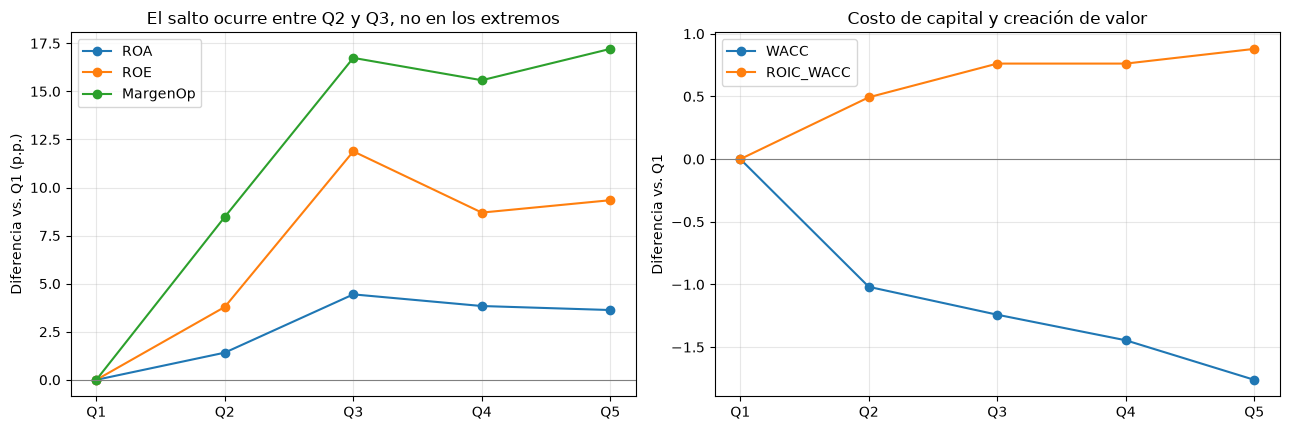

In [14]:
# Efecto escalonado: el perfil por quintil no impone forma funcional
perfil = []
for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC"]:
    m = modelos[y][2]
    fila = {"desempeno": y, "Q1 (referencia)": 0.0}
    for q in ["Q2", "Q3", "Q4", "Q5"]:
        fila[q] = m.params.get(f"C(qG)[T.{q}]", np.nan)
    perfil.append(fila)
perfil = pd.DataFrame(perfil).set_index("desempeno")
print("Efecto de cada quintil de gobierno frente a Q1, con controles:")
display(perfil.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for y in ["ROA", "ROE", "MargenOp"]:
    ax[0].plot(["Q1", "Q2", "Q3", "Q4", "Q5"], perfil.loc[y], marker="o", label=y)
ax[0].axhline(0, color="gray", lw=0.8)
ax[0].set_title("El salto ocurre entre Q2 y Q3, no en los extremos")
ax[0].set_ylabel("Diferencia vs. Q1 (p.p.)"); ax[0].legend()

for y in ["WACC", "ROIC_WACC"]:
    ax[1].plot(["Q1", "Q2", "Q3", "Q4", "Q5"], perfil.loc[y], marker="o", label=y)
ax[1].axhline(0, color="gray", lw=0.8)
ax[1].set_title("Costo de capital y creación de valor")
ax[1].set_ylabel("Diferencia vs. Q1"); ax[1].legend()
plt.tight_layout(); plt.show()

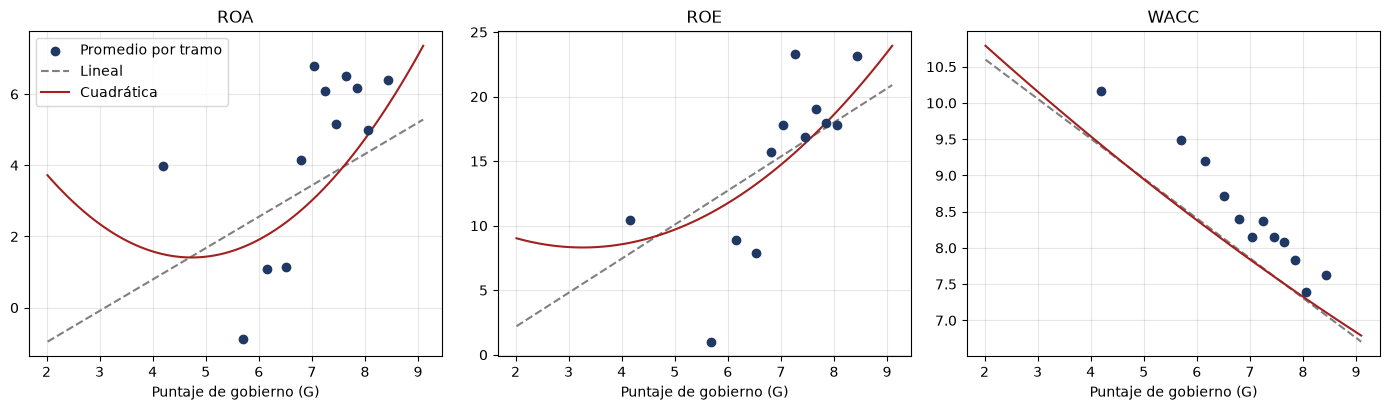

In [15]:
# Curva ajustada: lineal vs. cuadrática sobre los promedios por tramo de G
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for a, y in zip(ax, ["ROA", "ROE", "WACC"]):
    d = base.dropna(subset=[y, "DeudaActivos"])
    tramos = pd.qcut(d["G"], 12, duplicates="drop")
    obs = d.groupby(tramos, observed=True).agg(G=("G", "mean"), y=(y, "mean"))
    a.scatter(obs["G"], obs["y"], color="#1f3864", zorder=3, label="Promedio por tramo")

    m_lin, m_cua = modelos[y][0], modelos[y][1]
    rejilla = np.linspace(d["G"].min(), d["G"].max(), 100)
    fijo = {"logMC": d["logMC"].mean(), "DeudaActivos": d["DeudaActivos"].mean(),
            "Sector": d["Sector"].mode()[0]}
    p_lin = m_lin.predict(pd.DataFrame({"G": rejilla, **fijo}))
    p_cua = m_cua.predict(pd.DataFrame({"G": rejilla, "G2": rejilla ** 2, **fijo}))
    a.plot(rejilla, p_lin, "--", color="gray", label="Lineal")
    a.plot(rejilla, p_cua, "-", color="#a32020", label="Cuadrática")
    a.set_title(y); a.set_xlabel("Puntaje de gobierno (G)")
ax[0].legend()
plt.tight_layout(); plt.show()

## 4. Endogeneidad

La rúbrica pide usar los resultados para entender los problemas de endogeneidad entre las
características de la junta y el desempeño. Se documentan cuatro y se cuantifica cada uno
con los datos disponibles.

In [16]:
# 4.1 VARIABLE OMITIDA: el tamaño. Estabilidad del coeficiente al añadir controles.
especificaciones = {
    "(1) sin controles": "{y} ~ G",
    "(2) + tamaño": "{y} ~ G + logMC",
    "(3) + apalancamiento": "{y} ~ G + logMC + DeudaActivos",
    "(4) + sector": "{y} ~ G + logMC + DeudaActivos + C(Sector)",
}
filas = []
for y in ["ROA", "ROE", "MargenOp", "ROIC_WACC", "WACC"]:
    d = base.dropna(subset=[y, "DeudaActivos"])
    fila = {"desempeno": y}
    for nombre, f in especificaciones.items():
        fila[nombre] = ajustar(f.format(y=y), d).params["G"]
    filas.append(fila)
estabilidad = pd.DataFrame(filas).set_index("desempeno")
estabilidad["caida_%"] = (1 - estabilidad["(4) + sector"] / estabilidad["(1) sin controles"]) * 100
print("Coeficiente de G sobre el desempeño, según los controles incluidos:")
display(estabilidad.round(3))
print("La caída del coeficiente al controlar por tamaño mide cuánto del efecto bruto")
print("era en realidad tamaño. Si el coeficiente se moviera poco, el sesgo por variable")
print("omitida sería menor.")

Coeficiente de G sobre el desempeño, según los controles incluidos:


,(1) sin controles,(2) + tamaño,(3) + apalancamiento,(4) + sector,caida_%
desempeno,,,,,
ROA,1.198,0.862,0.869,0.882,26.442
ROE,3.969,3.095,2.648,2.640,33.494
MargenOp,5.201,4.497,4.517,3.808,26.781
ROIC_WACC,0.267,0.218,0.218,0.207,22.276
WACC,-0.658,-0.660,-0.621,-0.550,16.439


La caída del coeficiente al controlar por tamaño mide cuánto del efecto bruto
era en realidad tamaño. Si el coeficiente se moviera poco, el sesgo por variable
omitida sería menor.


In [17]:
# 4.2 CAUSALIDAD INVERSA: el gobierno también se explica por el tamaño y la rentabilidad.
d = base.dropna(subset=["ROA", "DeudaActivos"]).copy()
inv = ajustar("G ~ logMC + ROA + DeudaActivos + C(Sector)", d)
print("Regresión en sentido contrario (el gobierno como variable dependiente):")
print(inv.summary().tables[1])

# Para comparar las dos direcciones hay que ponerlas en la misma escala:
# se estandarizan ambas variables y se comparan los coeficientes beta.
d["zG"] = (d["G"] - d["G"].mean()) / d["G"].std()
d["zROA"] = (d["ROA"] - d["ROA"].mean()) / d["ROA"].std()
ida = ajustar("zROA ~ zG + logMC + DeudaActivos + C(Sector)", d)
vuelta = ajustar("zG ~ zROA + logMC + DeudaActivos + C(Sector)", d)

print(f"\nCoeficientes estandarizados (n = {int(ida.nobs):,}):")
print(f"  gobierno -> ROA : beta = {ida.params['zG']:+.3f}")
print(f"  ROA -> gobierno : beta = {vuelta.params['zROA']:+.3f}")
print("\nLas dos direcciones son indistinguibles en magnitud. La regresión no puede")
print("decidir cuál causa a cuál: es exactamente el problema de simultaneidad. Separarlas")
print("exigiría un panel con rezagos o un cambio regulatorio exógeno, que este archivo")
print("de un solo año no ofrece.")

Regresión en sentido contrario (el gobierno como variable dependiente):
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.7869      0.550      6.882      0.000       2.708       4.865
C(Sector)[T.Communications]            -1.4569      0.226     -6.444      0.000      -1.900      -1.014
C(Sector)[T.Consumer, Cyclical]        -0.3456      0.169     -2.043      0.041      -0.677      -0.014
C(Sector)[T.Consumer, Non-cyclical]    -0.3122      0.161     -1.937      0.053      -0.628       0.004
C(Sector)[T.Energy]                    -0.2740      0.218     -1.259      0.208      -0.701       0.153
C(Sector)[T.Financial]                 -0.1452      0.163     -0.891      0.373      -0.464       0.174
C(Sector)[T.Industrial]                -0.1038      0.161     -0.643      0.520      -0.420     

In [18]:
# 4.3 ERROR DE MEDIDA: el puntaje premia divulgar, no solo gobernar.
d = df[["G", "DivulgGob"]].dropna()
print(f"Correlación entre el pilar de gobierno y el puntaje de divulgación de gobierno:")
print(f"  Pearson = {d['G'].corr(d['DivulgGob']):.3f}   (n = {len(d):,})")

d2 = df[["DivulgGob", "logMC"]].dropna()
print(f"\nCorrelación entre divulgación y tamaño: {d2['DivulgGob'].corr(d2['logMC']):.3f}"
      f"   (n = {len(d2):,})")
print("\nDos tercios de la varianza del pilar de gobierno se explican por cuánto divulga la")
print("empresa: parte de lo que mide G es capacidad de reporte, no calidad de gobierno.")
print("En cambio, en las 158 empresas con dato de divulgación esta NO se asocia al tamaño,")
print("así que el sesgo de reporte no es simplemente un efecto de empresas grandes. La")
print("muestra es demasiado pequeña (8% del total) para afirmar más que eso.")

Correlación entre el pilar de gobierno y el puntaje de divulgación de gobierno:
  Pearson = 0.767   (n = 154)

Correlación entre divulgación y tamaño: -0.024   (n = 158)

Dos tercios de la varianza del pilar de gobierno se explican por cuánto divulga la
empresa: parte de lo que mide G es capacidad de reporte, no calidad de gobierno.
En cambio, en las 158 empresas con dato de divulgación esta NO se asocia al tamaño,
así que el sesgo de reporte no es simplemente un efecto de empresas grandes. La
muestra es demasiado pequeña (8% del total) para afirmar más que eso.


In [19]:
# 4.4 SIMULTANEIDAD: las características de la junta se determinan con el tamaño de la firma.
simult = []
for v in JUNTA:
    d = df[[v, "logMC"]].dropna()
    simult.append({"caracteristica": v, "n": len(d),
                   "corr_con_tamano": d[v].corr(d["logMC"])})
simult = pd.DataFrame(simult).set_index("caracteristica")
print("Correlación de cada característica de junta con el tamaño de la firma:")
display(simult.round(3))
print("El tamaño de la junta es la más endógena: las empresas grandes tienen juntas grandes")
print("por razones operativas, no de gobierno. Cualquier efecto crudo del tamaño de junta")
print("sobre el desempeño está confundido con el tamaño de la empresa.")

Correlación de cada característica de junta con el tamaño de la firma:


,n,corr_con_tamano
caracteristica,,
PctIndep,381,0.150
TamJunta,438,0.259
EdadJunta,432,0.067
PctMujeresJunta,437,0.220


El tamaño de la junta es la más endógena: las empresas grandes tienen juntas grandes
por razones operativas, no de gobierno. Cualquier efecto crudo del tamaño de junta
sobre el desempeño está confundido con el tamaño de la empresa.


In [20]:
# 4.5 ¿Sirve una variable instrumental? El promedio sectorial de G como instrumento.
base["G_sector"] = base.groupby("Sector")["G"].transform("mean")
primera = ajustar("G ~ G_sector + logMC + DeudaActivos", base.dropna(subset=["DeudaActivos"]))
print("Primera etapa (G explicado por el promedio de su sector):")
print(f"  coeficiente = {primera.params['G_sector']:.3f}   F parcial = "
      f"{float(np.ravel(primera.f_test('G_sector = 0').fvalue)[0]):.1f}")
print("\nEl instrumento es fuerte en la primera etapa, pero NO cumple la restricción de")
print("exclusión: el sector afecta la rentabilidad por vías distintas del gobierno")
print("(intensidad de capital, ciclo, regulación). Por eso el ejercicio se queda en")
print("asociación con controles y no pretende identificar un efecto causal.")

Primera etapa (G explicado por el promedio de su sector):
  coeficiente = 1.052   F parcial = 90.9

El instrumento es fuerte en la primera etapa, pero NO cumple la restricción de
exclusión: el sector afecta la rentabilidad por vías distintas del gobierno
(intensidad de capital, ciclo, regulación). Por eso el ejercicio se queda en
asociación con controles y no pretende identificar un efecto causal.


## 5. Exportación de resultados

In [21]:
ARCHIVO = "resultados_taller1.xlsx"
with pd.ExcelWriter(ARCHIVO, engine="openpyxl") as w:
    tabla_asg.to_excel(w, sheet_name="desc_asg")
    tabla_junta.to_excel(w, sheet_name="desc_junta")
    tabla_comp.to_excel(w, sheet_name="desc_compensacion")
    prevalencia.to_excel(w, sheet_name="desc_antitoma")
    tabla_blindaje_G.to_excel(w, sheet_name="antitoma_vs_G")
    cov.to_excel(w, sheet_name="covarianza")
    corr_p.to_excel(w, sheet_name="corr_pearson")
    corr_s.to_excel(w, sheet_name="corr_spearman")
    tabla_nolineal.to_excel(w, sheet_name="no_lineal")
    perfil.to_excel(w, sheet_name="perfil_quintiles")
    estabilidad.to_excel(w, sheet_name="endog_estabilidad")
    simult.to_excel(w, sheet_name="endog_simultaneidad")
print(f"Resultados exportados a {ARCHIVO}")

Resultados exportados a resultados_taller1.xlsx
